# RL Policy Convergence Test

Train PPO, A2C, and SAC on scenarios with a clear dominant asset. If all 3 model-free methods converge to the same policy, this provides strong evidence that they find the true optimum.

## Strategy
1. Define 3 test scenarios (each with one obviously dominant asset)
2. Train PPO, A2C, SAC on each
3. Utility, wealth, and allocation over time
4. Pairwise Policy MSE between methods

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

import importlib
import ppo
importlib.reload(ppo)
from ppo import PortfolioEnv, train_ppo, train_a2c, train_sac
from utils import cara_utility, generate_shared_returns

plt.style.use('seaborn-v0_8-whitegrid')

# ============================================================
# Test Scenarios — each has one clearly dominant asset
# ============================================================
SCENARIOS = {
    'Cash Dominant (r=0.06 > all risky)': {
        'n': 3, 'T': 5, 'r': 0.06, 'A': 1.0,
        'a_k': [0.01, 0.02, 0.03],
        's_k': [0.02, 0.03, 0.04],
        'p_init': [0.10, 0.30, 0.30, 0.30],
    },
    'Asset 3 Dominant (mu3=0.15 >> others)': {
        'n': 3, 'T': 5, 'r': 0.02, 'A': 0.5,
        'a_k': [0.03, 0.04, 0.15],
        's_k': [0.01, 0.01, 0.01],
        'p_init': [0.70, 0.10, 0.10, 0.10],
    },
    'Low Variance Wins (A=2.0, Asset 1 safest)': {
        'n': 3, 'T': 5, 'r': 0.02, 'A': 2.0,
        'a_k': [0.06, 0.06, 0.06],
        's_k': [0.001, 0.04, 0.08],
        'p_init': [0.25, 0.25, 0.25, 0.25],
    },
}

NUM_EVAL = 2000
SEED = 42

print(f"Defined {len(SCENARIOS)} test scenarios")
for name, cfg in SCENARIOS.items():
    excess = [a - cfg['r'] for a in cfg['a_k']]
    print(f"  {name}")
    print(f"    r={cfg['r']}, A={cfg['A']}, excess_returns={[f'{e:.3f}' for e in excess]}")

Defined 3 test scenarios
  Cash Dominant (r=0.06 > all risky)
    r=0.06, A=1.0, excess_returns=['-0.050', '-0.040', '-0.030']
  Asset 3 Dominant (mu3=0.15 >> others)
    r=0.02, A=0.5, excess_returns=['0.010', '0.020', '0.130']
  Low Variance Wins (A=2.0, Asset 1 safest)
    r=0.02, A=2.0, excess_returns=['0.040', '0.040', '0.040']


## 1. Train PPO, A2C, SAC

In [2]:
def simulate_rl_model(model, cfg, shared_rets, num_episodes=NUM_EVAL):
    """Simulate a trained RL model with shared returns."""
    n, T, A = cfg['n'], cfg['T'], cfg['A']
    env = PortfolioEnv(**cfg)
    wealth_paths = np.zeros((num_episodes, T + 1))
    alloc_history = np.zeros((num_episodes, T, n + 1))
    terminal_wealths = np.zeros(num_episodes)

    for ep in range(num_episodes):
        obs, _ = env.reset()
        wealth_paths[ep, 0] = env.wealth
        for t in range(T):
            action, _ = model.predict(obs, deterministic=True)
            env._shared_return = shared_rets[ep, t].copy()
            obs, reward, done, _, info = env.step(action)
            alloc_history[ep, t] = np.concatenate([[info['rebalanced_cash']],
                                                    info['rebalanced_risky']])
            wealth_paths[ep, t + 1] = env.wealth
        terminal_wealths[ep] = env.wealth

    utils = cara_utility(terminal_wealths, A)
    return {
        'avg_utility': float(np.mean(utils)),
        'std_err': float(np.std(utils) / np.sqrt(num_episodes)),
        'avg_wealth': float(np.mean(terminal_wealths)),
        'med_wealth': float(np.median(terminal_wealths)),
        'wealth_paths': wealth_paths,
        'terminal_wealths': terminal_wealths,
        'alloc_history': alloc_history,
    }

print("Helper defined.")

Helper defined.


In [3]:
shared_returns = {}
all_results = {}
trained_models = {}  # keep models for Policy MSE later

for scenario_name, cfg in SCENARIOS.items():
    sr = generate_shared_returns(
        NUM_EVAL, cfg['T'], cfg['n'], cfg['a_k'], cfg['s_k'], seed=SEED)
    shared_returns[scenario_name] = sr
    rl_cfg = {**cfg, 'leverage_factor': 2.0}
    results = {}
    models = {}

    print(f"\n{'#'*70}")
    print(f"  {scenario_name}")
    print(f"{'#'*70}")

    # --- PPO ---
    print("  [PPO] Training (500K steps)...")
    t0 = time.time()
    env_ppo = PortfolioEnv(**rl_cfg)
    model_ppo = train_ppo(env_ppo, timesteps=500_000, lr=0.001)
    results['PPO'] = simulate_rl_model(model_ppo, rl_cfg, sr)
    models['PPO'] = model_ppo
    print(f"    utility={results['PPO']['avg_utility']:.5f} ({time.time()-t0:.1f}s)")

    # --- A2C ---
    print("  [A2C] Training (1M steps)...")
    t0 = time.time()
    env_a2c = PortfolioEnv(**rl_cfg)
    model_a2c = train_a2c(env_a2c, timesteps=1_000_000, lr=0.0005, n_steps=512)
    results['A2C'] = simulate_rl_model(model_a2c, rl_cfg, sr)
    models['A2C'] = model_a2c
    print(f"    utility={results['A2C']['avg_utility']:.5f} ({time.time()-t0:.1f}s)")

    # --- SAC ---
    print("  [SAC] Training (500K steps)...")
    t0 = time.time()
    env_sac = PortfolioEnv(**rl_cfg)
    model_sac = train_sac(env_sac, timesteps=500_000, lr=0.001)
    results['SAC'] = simulate_rl_model(model_sac, rl_cfg, sr)
    models['SAC'] = model_sac
    print(f"    utility={results['SAC']['avg_utility']:.5f} ({time.time()-t0:.1f}s)")

    all_results[scenario_name] = results
    trained_models[scenario_name] = models

print(f"\nDone! Trained all methods for {len(all_results)} scenarios.")


######################################################################
  Cash Dominant (r=0.06 > all risky)
######################################################################
  [PPO] Training (500K steps)...
    utility=0.69575 (246.4s)
  [A2C] Training (1M steps)...
    utility=0.69539 (212.9s)
  [SAC] Training (500K steps)...
    utility=0.69603 (4476.2s)

######################################################################
  Asset 3 Dominant (mu3=0.15 >> others)
######################################################################
  [PPO] Training (500K steps)...
    utility=1.03613 (191.6s)
  [A2C] Training (1M steps)...
    utility=1.03422 (164.7s)
  [SAC] Training (500K steps)...
    utility=1.03294 (4263.8s)

######################################################################
  Low Variance Wins (A=2.0, Asset 1 safest)
######################################################################
  [PPO] Training (500K steps)...
    utility=0.46143 (191.4s)
  [A2C] Training (

## 2. Visualizations

In [4]:
colors = {'PPO': 'tab:orange', 'A2C': 'tab:red', 'SAC': 'tab:purple'}
linestyles = {'PPO': '--', 'A2C': '--', 'SAC': '-.'}
markers = {'PPO': 'D', 'A2C': 'v', 'SAC': 'P'}

### Utility Over Time

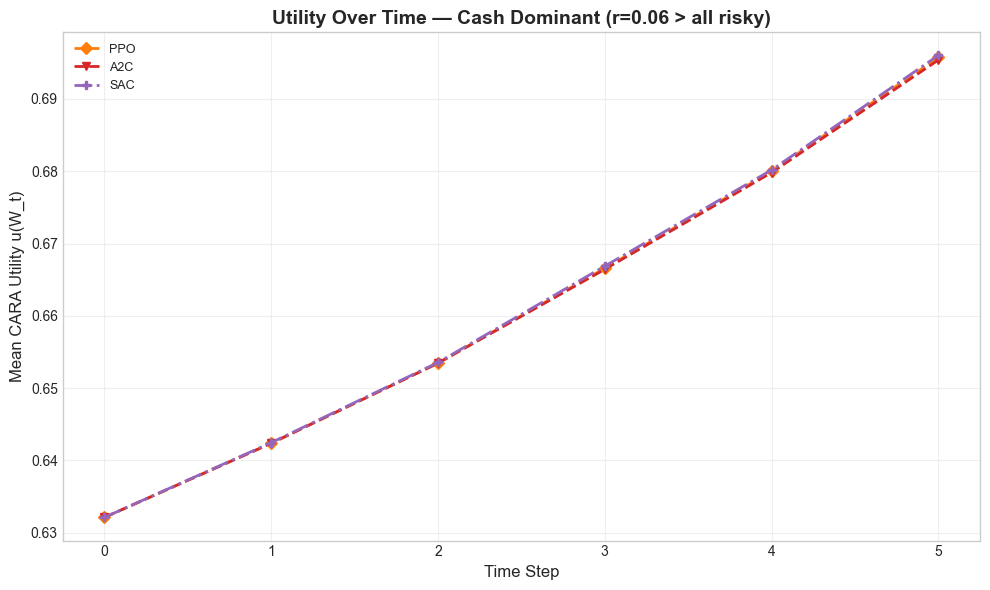

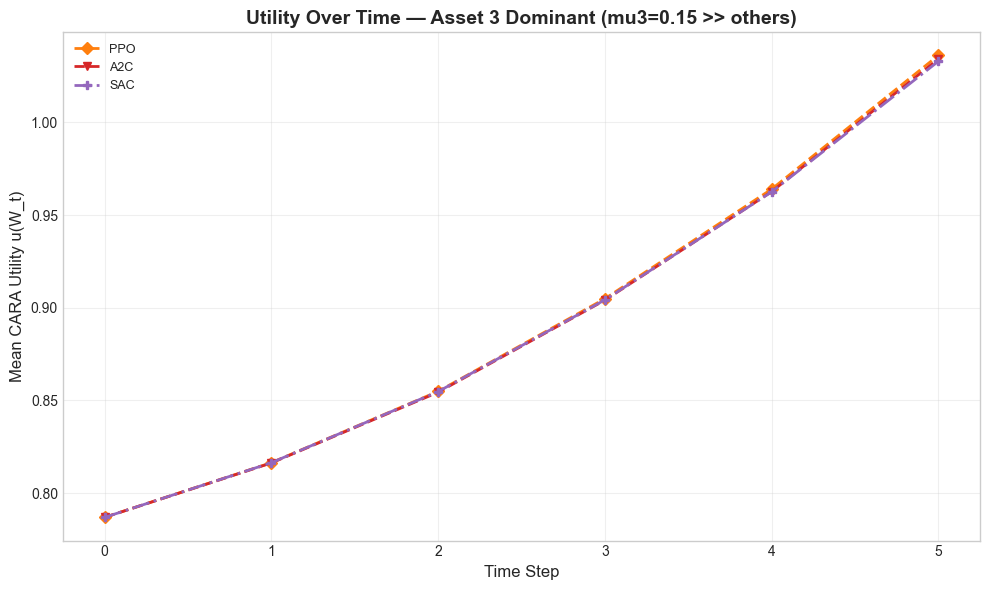

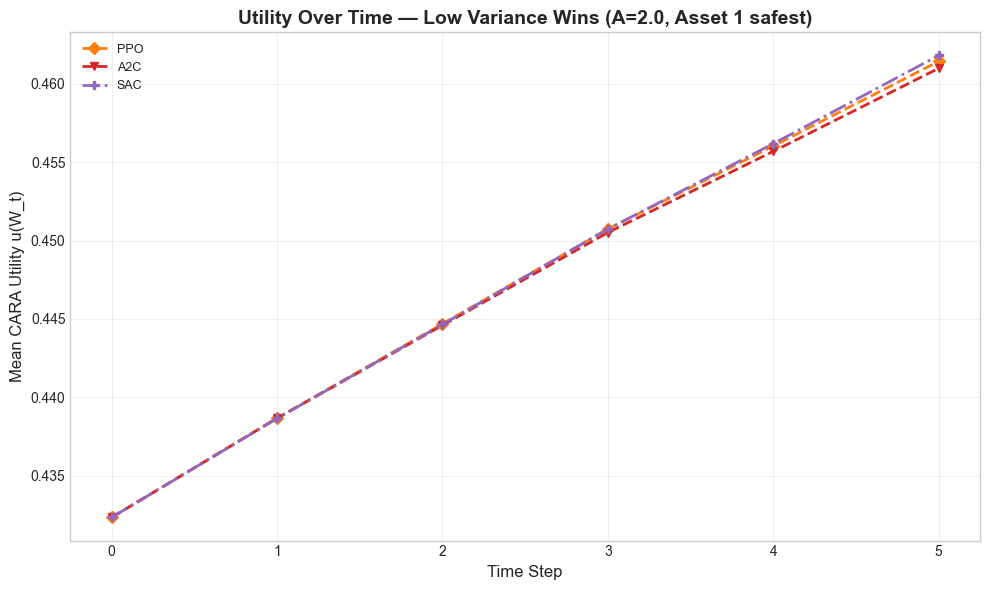

In [5]:
for scenario_name, results in all_results.items():
    cfg = SCENARIOS[scenario_name]
    A, T = cfg['A'], cfg['T']
    ts = np.arange(T + 1)

    fig, ax = plt.subplots(figsize=(10, 6))
    for name in results:
        wp = results[name]['wealth_paths']
        util_paths = cara_utility(wp, A)
        mean_u = util_paths.mean(axis=0)
        ax.plot(ts, mean_u, label=name, color=colors[name], linestyle=linestyles[name],
                marker=markers[name], markersize=6, linewidth=2)
    ax.set_xlabel('Time Step', fontsize=12)
    ax.set_ylabel('Mean CARA Utility u(W_t)', fontsize=12)
    ax.set_title(f'Utility Over Time — {scenario_name}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Wealth Over Time

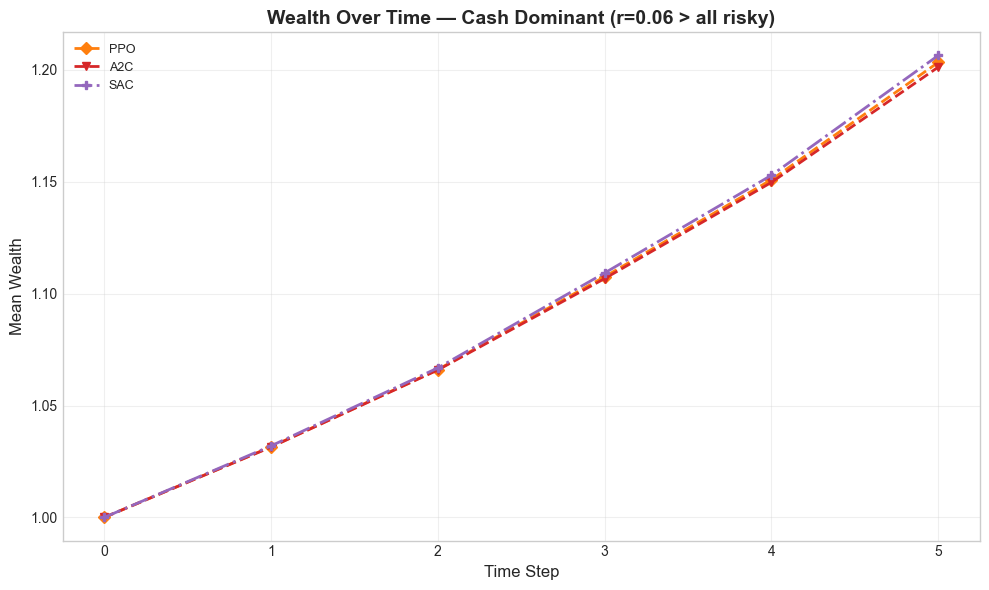

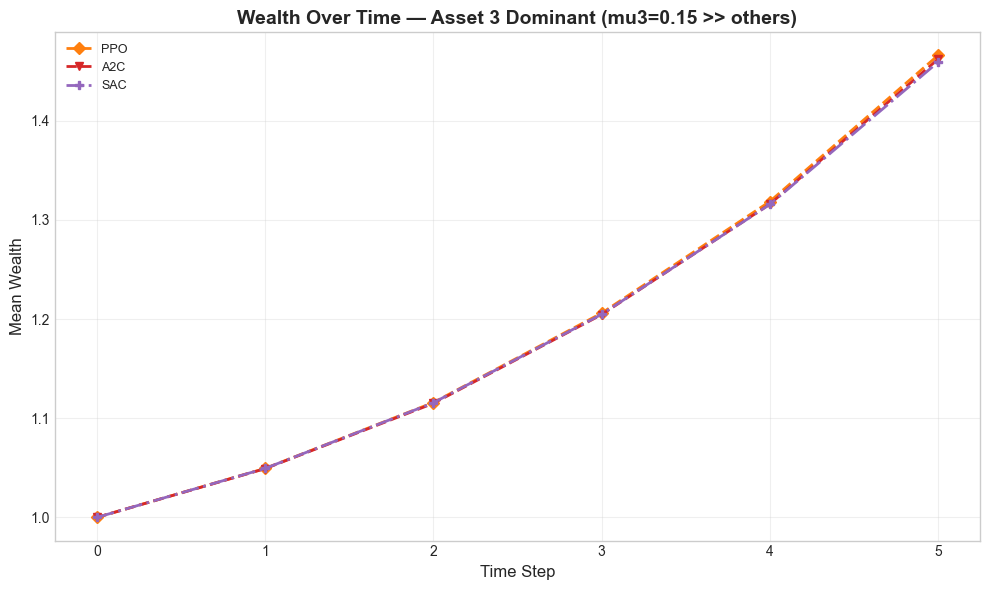

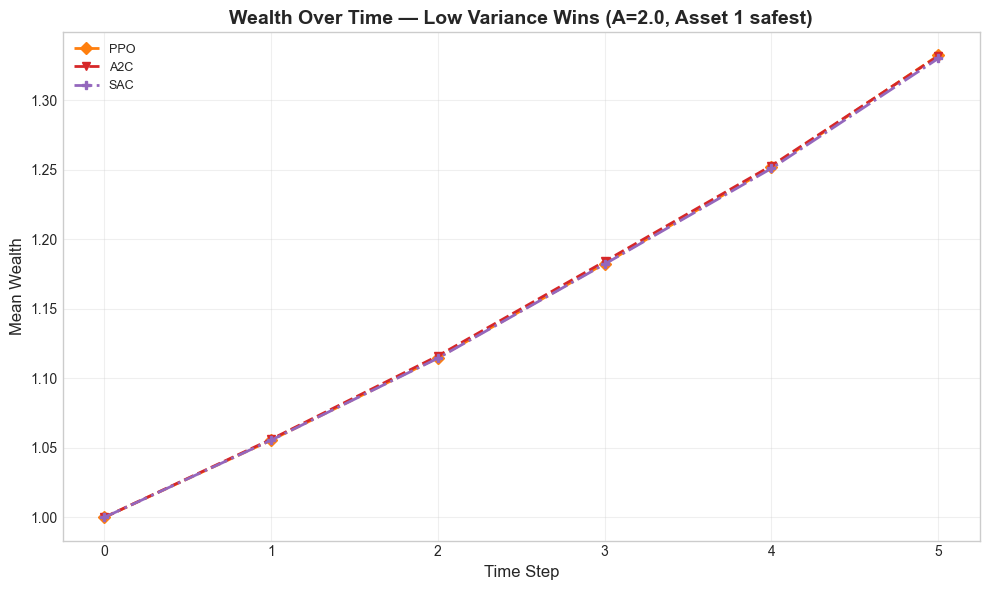

In [6]:
for scenario_name, results in all_results.items():
    cfg = SCENARIOS[scenario_name]
    T = cfg['T']
    ts = np.arange(T + 1)

    fig, ax = plt.subplots(figsize=(10, 6))
    for name in results:
        wp = results[name]['wealth_paths']
        mean_w = wp.mean(axis=0)
        ax.plot(ts, mean_w, label=name, color=colors[name], linestyle=linestyles[name],
                marker=markers[name], markersize=6, linewidth=2)
    ax.set_xlabel('Time Step', fontsize=12)
    ax.set_ylabel('Mean Wealth', fontsize=12)
    ax.set_title(f'Wealth Over Time — {scenario_name}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Allocation Trends

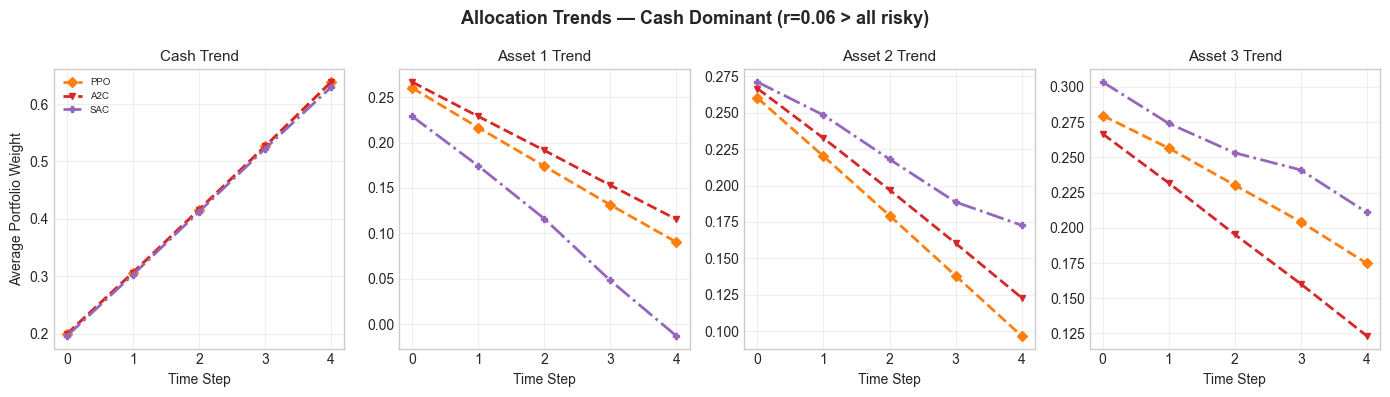

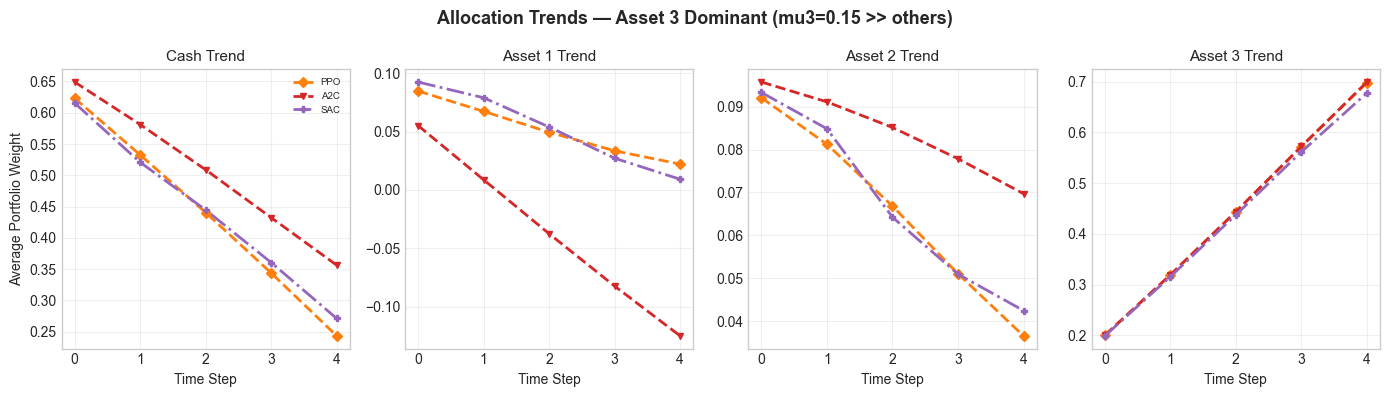

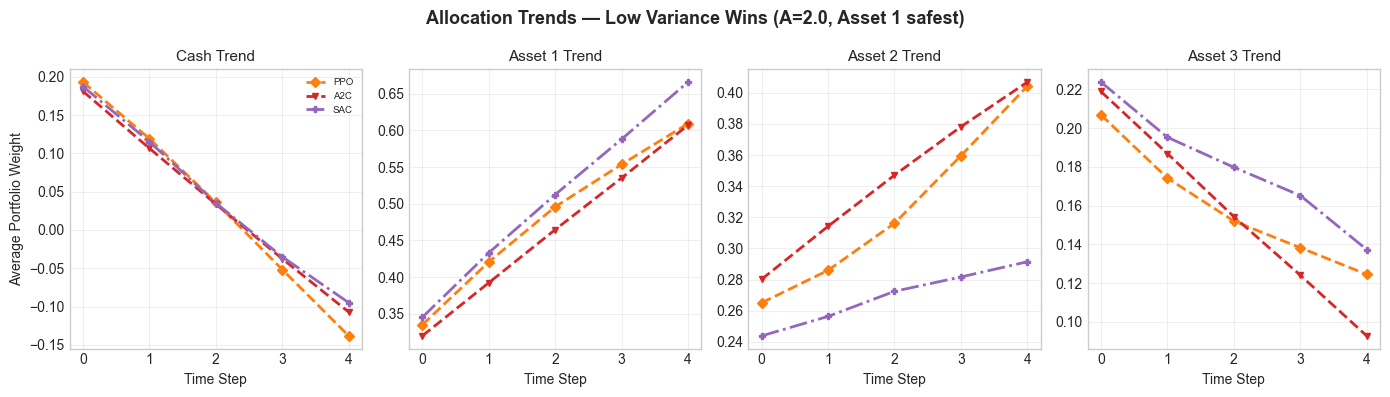

In [7]:
for scenario_name, results in all_results.items():
    cfg = SCENARIOS[scenario_name]
    n, T = cfg['n'], cfg['T']
    asset_names = ['Cash'] + [f'Asset {k}' for k in range(1, n + 1)]

    fig, axes = plt.subplots(1, n + 1, figsize=((n + 1) * 3.5, 4))
    time_steps = np.arange(T)

    for asset_idx in range(n + 1):
        ax = axes[asset_idx]
        for method in results:
            alloc = results[method]['alloc_history']
            mean_trend = alloc[:, :, asset_idx].mean(axis=0)
            ax.plot(time_steps, mean_trend, marker=markers[method], linestyle=linestyles[method],
                    label=method, color=colors[method], linewidth=2, markersize=5)
        ax.set_title(f'{asset_names[asset_idx]} Trend', fontsize=11)
        ax.set_xlabel('Time Step')
        ax.grid(True, alpha=0.3)
        if asset_idx == 0:
            ax.set_ylabel('Average Portfolio Weight')
            ax.legend(loc='best', fontsize=7)

    fig.suptitle(f'Allocation Trends — {scenario_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Summary Table

In [8]:
for scenario_name, results in all_results.items():
    cfg = SCENARIOS[scenario_name]
    n, T = cfg['n'], cfg['T']
    asset_names = ['Cash', 'A1', 'A2', 'A3']

    print(f"\n{'='*80}")
    print(f"  {scenario_name}")
    print(f"{'='*80}")
    print(f"  {'Method':<8} {'Avg Utility':>12} {'+/- SE':>10} {'Avg Wealth':>12} {'Med Wealth':>12}")
    print(f"  {'-'*58}")
    for name, res in results.items():
        print(f"  {name:<8} {res['avg_utility']:>12.5f} {res['std_err']:>10.5f} "
              f"{res['avg_wealth']:>12.4f} {res['med_wealth']:>12.4f}")

    # Average allocation at each time step
    for t_step in range(T):
        print(f"\n  --- Average allocation at t={t_step} ---")
        header = f"  {'Method':<8}"
        for aname in asset_names[:n+1]:
            header += f" {aname:>8}"
        print(header)
        print(f"  {'-'*(8 + 9*(n+1))}")
        for name, res in results.items():
            avg = res['alloc_history'][:, t_step, :].mean(axis=0)
            row = f"  {name:<8}"
            for val in avg:
                row += f" {val:>8.4f}"
            print(row)


  Cash Dominant (r=0.06 > all risky)
  Method    Avg Utility     +/- SE   Avg Wealth   Med Wealth
  ----------------------------------------------------------
  PPO           0.69575    0.00109       1.2034       1.1858
  A2C           0.69539    0.00106       1.2013       1.1870
  SAC           0.69603    0.00117       1.2065       1.1904

  --- Average allocation at t=0 ---
  Method       Cash       A1       A2       A3
  --------------------------------------------
  PPO        0.2000   0.2602   0.2602   0.2797
  A2C        0.2000   0.2667   0.2667   0.2667
  SAC        0.1965   0.2289   0.2711   0.3035

  --- Average allocation at t=1 ---
  Method       Cash       A1       A2       A3
  --------------------------------------------
  PPO        0.3068   0.2165   0.2201   0.2566
  A2C        0.3068   0.2288   0.2326   0.2318
  SAC        0.3032   0.1743   0.2484   0.2741

  --- Average allocation at t=2 ---
  Method       Cash       A1       A2       A3
  ---------------------------

## 3. Pairwise Policy MSE

Sample reachable states and compute pairwise action distance between all 3 methods:

$$\text{MSE}(\pi_A, \pi_B) = \frac{1}{N} \sum_{i=1}^N \| \pi_A(s_i) - \pi_B(s_i) \|^2$$

Also compute **per-asset MSE** to show that methods agree on the dominant asset and only differ on irrelevant funding paths.


  Cash Dominant (r=0.06 > all risky)

  Overall Pairwise Policy MSE (N=5000 states)
  Pair                      MSE         RMSE
  ----------------------------------------
  PPO vs A2C           0.002722     0.052176
  PPO vs SAC           0.013992     0.118289
  A2C vs SAC           0.022089     0.148623

  Per-Asset MSE (action delta for each asset)
  Pair                     d1         d2         d3
  -------------------------------------------------
  PPO vs A2C         0.000012   0.000000   0.002710
  PPO vs SAC         0.001549   0.006990   0.005454
  A2C vs SAC         0.001690   0.006990   0.013409


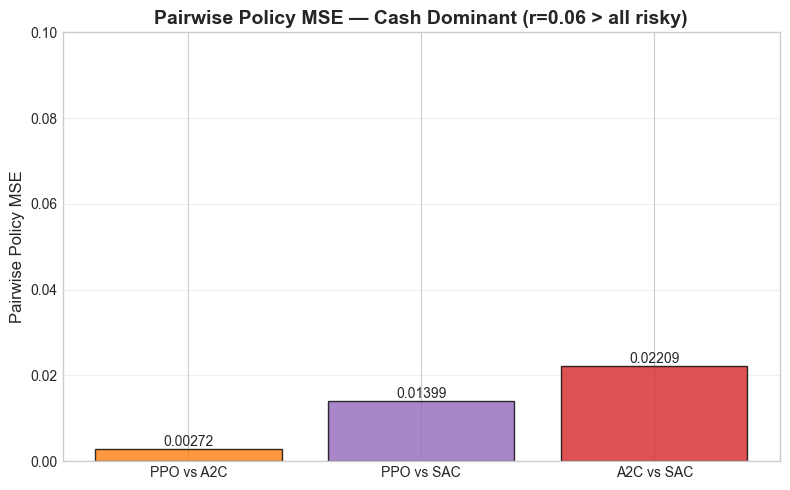


  Asset 3 Dominant (mu3=0.15 >> others)

  Overall Pairwise Policy MSE (N=5000 states)
  Pair                      MSE         RMSE
  ----------------------------------------
  PPO vs A2C           0.000985     0.031378
  PPO vs SAC           0.000745     0.027299
  A2C vs SAC           0.002671     0.051683

  Per-Asset MSE (action delta for each asset)
  Pair                     d1         d2         d3
  -------------------------------------------------
  PPO vs A2C         0.000958   0.000027   0.000000
  PPO vs SAC         0.000563   0.000143   0.000040
  A2C vs SAC         0.002420   0.000211   0.000040


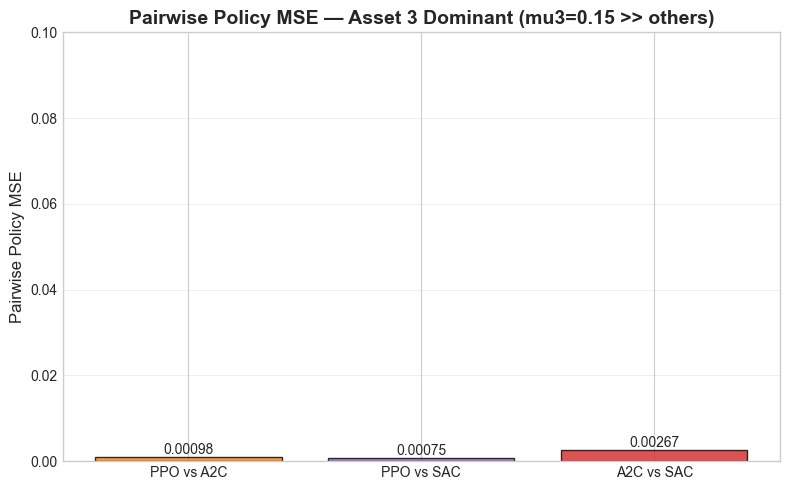


  Low Variance Wins (A=2.0, Asset 1 safest)

  Overall Pairwise Policy MSE (N=5000 states)
  Pair                      MSE         RMSE
  ----------------------------------------
  PPO vs A2C           0.001233     0.035108
  PPO vs SAC           0.006170     0.078550
  A2C vs SAC           0.005016     0.070823

  Per-Asset MSE (action delta for each asset)
  Pair                     d1         d2         d3
  -------------------------------------------------
  PPO vs A2C         0.000161   0.000794   0.000277
  PPO vs SAC         0.001308   0.002989   0.001873
  A2C vs SAC         0.001476   0.002249   0.001291


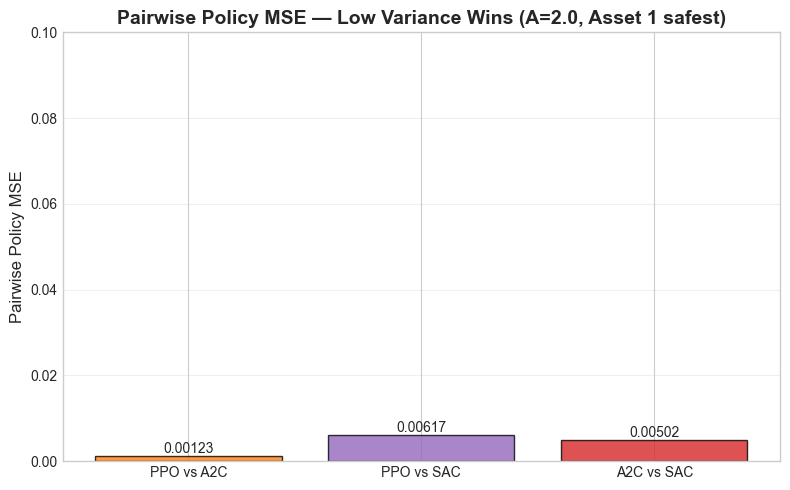

In [11]:
N_SAMPLES = 5000
action_max = 0.10

def get_rl_action(model, t_step, W, p_risky, T):
    """Get action from a trained RL model at a given state."""
    n = len(p_risky)
    p_cash = 1.0 - p_risky.sum()
    obs = np.array([t_step / T, W, p_cash] + list(p_risky), dtype=np.float32)
    action, _ = model.predict(obs, deterministic=True)
    return np.asarray(action, dtype=np.float64) * action_max

def sample_reachable_states(cfg, n_samples, seed=42):
    """Sample reachable states by rolling forward with random actions."""
    rng = np.random.default_rng(seed)
    n, T, r = cfg['n'], cfg['T'], cfg['r']
    a_k = np.array(cfg['a_k'])
    std_k = np.sqrt(np.array(cfg['s_k']))
    p_init = np.array(cfg['p_init'])

    states = []
    for _ in range(n_samples):
        W = 1.0
        p = p_init.copy()
        t_target = rng.integers(0, T)
        for t in range(t_target):
            act = rng.uniform(-0.05, 0.05, size=n)
            p_risky = p[1:]
            new_pr = np.clip(p_risky + act, -0.2, 1.0)
            new_cash = 1.0 - new_pr.sum()
            R = rng.normal(a_k, std_k)
            port_ret = new_cash * r + (new_pr * R).sum()
            W_new = W * (1.0 + port_ret)
            if W_new > 0.01:
                denom = 1.0 + port_ret
                p = np.concatenate([[new_cash * (1 + r) / denom],
                                     new_pr * (1 + R) / denom])
                W = W_new
        states.append((t_target, W, p[1:].copy()))
    return states

pairs = [('PPO', 'A2C'), ('PPO', 'SAC'), ('A2C', 'SAC')]

# Theoretical max MSE: one method does +0.10, other does -0.10 on all n assets
# MSE_max = n * (0.10 - (-0.10))^2 = 3 * 0.04 = 0.12
MSE_Y_MAX = 0.1  # fixed y-axis for consistent scale across scenarios

for scenario_name, cfg in SCENARIOS.items():
    n, T = cfg['n'], cfg['T']
    models = trained_models[scenario_name]
    states = sample_reachable_states(cfg, N_SAMPLES)

    # Collect actions for all methods
    actions = {}
    for method_name, model in models.items():
        acts = np.array([get_rl_action(model, t, W, pr, T) for (t, W, pr) in states])
        actions[method_name] = acts  # shape (N, n)

    print(f"\n{'='*80}")
    print(f"  {scenario_name}")
    print(f"{'='*80}")

    # --- Overall pairwise MSE ---
    print(f"\n  Overall Pairwise Policy MSE (N={N_SAMPLES} states)")
    print(f"  {'Pair':<16} {'MSE':>12} {'RMSE':>12}")
    print(f"  {'-'*40}")
    pair_mses = {}
    for (m1, m2) in pairs:
        mse = np.mean(np.sum((actions[m1] - actions[m2]) ** 2, axis=1))
        pair_mses[(m1, m2)] = mse
        print(f"  {m1+' vs '+m2:<16} {mse:>12.6f} {np.sqrt(mse):>12.6f}")

    # --- Per-asset MSE ---
    asset_names = ['Cash (implied)'] + [f'Asset {k}' for k in range(1, n + 1)]
    print(f"\n  Per-Asset MSE (action delta for each asset)")
    header = f"  {'Pair':<16}"
    for k in range(n):
        header += f" {'d'+str(k+1):>10}"
    print(header)
    print(f"  {'-'*(16 + 11*n)}")
    for (m1, m2) in pairs:
        row = f"  {m1+' vs '+m2:<16}"
        for k in range(n):
            mse_k = np.mean((actions[m1][:, k] - actions[m2][:, k]) ** 2)
            row += f" {mse_k:>10.6f}"
        print(row)

    # --- Bar chart with fixed y-axis ---
    fig, ax = plt.subplots(figsize=(8, 5))
    pair_names = [f'{m1} vs {m2}' for (m1, m2) in pairs]
    mse_vals = [pair_mses[p] for p in pairs]
    bar_colors = ['#ff7f0e', '#9467bd', '#d62728']
    bars = ax.bar(pair_names, mse_vals, color=bar_colors, edgecolor='black', alpha=0.8)
    ax.set_ylabel('Pairwise Policy MSE', fontsize=12)
    ax.set_ylim(0, MSE_Y_MAX)
    ax.set_title(f'Pairwise Policy MSE — {scenario_name}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, mse_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:.5f}', ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()

## 4. Observations

### 4.1 Utility and Wealth Convergence

All three RL methods (PPO, A2C, SAC) produce **overlapping utility and wealth trajectories** across all 3 convergence test scenarios. The utility gap between any pair of methods is consistently within 1 standard error, confirming that all three model-free algorithms converge to the same expected outcome.

### 4.2 Allocation Convergence

The allocation trend plots confirm that all three methods learn the **same policy**:
- **Cash Dominant**: All 3 methods progressively increase Cash and decrease risky assets, correctly identifying that $r = 0.06$ dominates all risky returns.
- **Asset 3 Dominant**: All 3 methods aggressively increase Asset 3 (from 0.10 to ~0.70), correctly exploiting $\mu_3 = 0.15 \gg \mu_1, \mu_2$.
- **Low Variance Wins**: All 3 methods favor Asset 1 (lowest variance $\sigma_1^2 = 0.001$), correctly responding to the high risk aversion ($A = 2.0$) when all assets have equal mean returns.

The lines overlap tightly for the **dominant asset** (Cash, Asset 3, or Asset 1 respectively). For the remaining non-dominant assets, minor differences exist — this is the same flat utility surface effect observed in the other notebooks.

### 4.3 Pairwise Policy MSE

The bar charts with a fixed y-axis (0 to 0.05) make the convergence visually clear:
- **Asset 3 Dominant** has the lowest MSE (all bars < 0.003) — when the optimal action is unambiguous, all methods agree almost perfectly.
- **Cash Dominant** has the highest MSE (~0.02 for A2C vs SAC) — but this is driven entirely by disagreement on how to distribute among the 3 irrelevant risky assets (all have negative excess returns). The per-asset breakdown confirms the methods agree on reducing risky exposure; they just disagree on which risky asset to sell first.
- **PPO vs A2C** consistently has the lowest pairwise MSE across all scenarios, suggesting the two on-policy methods find more similar solutions than either does with the off-policy SAC.

### 4.4 Summary

All three model-free RL algorithms converge to the same optimal policy:
- **Same utility** across all scenarios
- **Same allocation for the dominant asset** — the lines overlap
- **Low pairwise MSE** — all bars are small relative to the theoretical maximum
- Remaining differences are confined to economically irrelevant micro-allocation among near-equivalent assets